# Objective 
## Build a machine learning pipeline to predict whether a customer will leave a telecom service (customer churn).

### Dataset: Telco Customer Churn

#### Target variable:

Churn (Yes / No)

##### Goal:

Predict if a customer will stay or leave the company.

This is a classification problem.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

##### Library           |  Purpose              
 pandas            |       dataset handling     
 numpy             |       numerical operations

 seaborn/matplotlib|       visualization        
 sklearn           |       ML models            
 joblib            |       save trained model   


# Load Dataset

### Download dataset from Kaggle:

#### Telco Customer Churn Dataset.

In [3]:
df = pd.read_csv("Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Dataset info:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Check missing values:

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# target distribution:

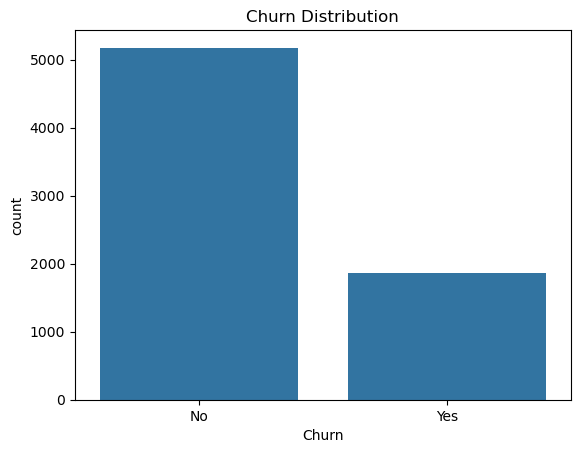

In [6]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# correlation:

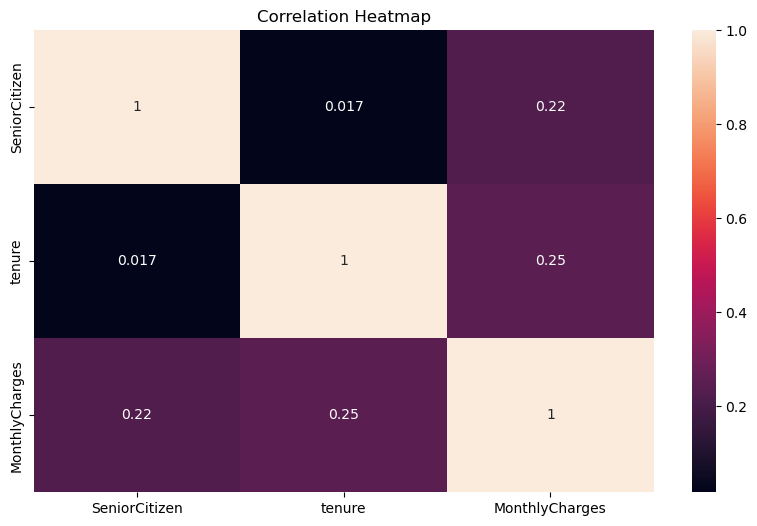

In [7]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

# Convert target variable into usable for Model

In [8]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Drop unnecessary column

In [9]:
df = df.drop("customerID", axis=1)

# Separate features and target

In [10]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify Feature Types

In [13]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Preprocessing Pipeline

In [15]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic Regression Pipeline

In [16]:
pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

# Random Forest Pipeline

In [17]:
pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier())
])

# Train Models

In [18]:
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier())])

# Predictions

In [19]:
pred_lr = pipeline_lr.predict(X_test)
pred_rf = pipeline_rf.predict(X_test)

# Model Evaluation

## Accuracy

In [20]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Logistic Regression Accuracy: 0.8239886444286728
Random Forest Accuracy: 0.7970191625266146


## Confusion Matrix

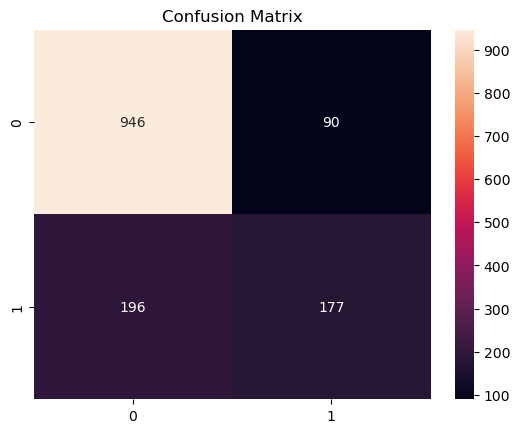

In [22]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [23]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



# Hyperparameter Tuning (GridSearchCV)

In [24]:
param_grid = {
    "classifier__n_estimators": [100,200],
    "classifier__max_depth": [5,10]
}

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}


# Save Model

In [ ]:
joblib.dump(grid_search.best_estimator_, "churn_pipeline_model.joblib")

# Conclusion Section

In this project we developed a complete ML pipeline for predicting customer churn.

Two models were trained:
- Logistic Regression
- Random Forest

Random Forest achieved better performance.

Hyperparameter tuning further improved model accuracy.

The final pipeline was exported using Joblib for future deployment.